In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.decomposition import PCA, FastICA
import matplotlib.pyplot as plt
import seaborn as sns
import panphon
from sklearn.metrics import average_precision_score

In [4]:
arpa_ipa = {'aa': 'ɑ', 'ae': 'æ', 'ah': 'ʌ', 'ao': 'ɔ', 'aw': 'aʊ', 'ax': 'ə', 'ax-h': 'ə̥', 'axr': 'ɚ', 'ay': 'aɪ', 'b': 'b', 'ch': 'tʃ', 'd': 'd', 'dh': 'ð', 'dx': 'ɾ', 'eh': 'ɛ', 'el': 'l̩', 'em': 'm̩', 'en': 'n̩', 'eng': 'ŋ̍', 'er': 'ɝ', 'ey': 'eɪ', 'f': 'f', 'g': 'ɡ', 'hh': 'h', 'hv': 'ɦ', 'ih': 'ɪ', 'ix': 'ɨ', 'iy': 'i', 'jh': 'dʒ', 'k': 'k', 'l': 'l', 'm': 'm', 'n': 'n', 'ng': 'ŋ', 'nx': 'ɾ̃', 'ow': 'oʊ', 'oy': 'ɔɪ', 'p': 'p', 'r': 'ɹ', 's': 's', 'sh': 'ʃ', 't': 't', 'th': 'θ', 'uh': 'ʊ', 'uw': 'u', 'ux': 'ʉ', 'v': 'v', 'w': 'w', 'y': 'j', 'z': 'z', 'zh': 'ʒ'}

panphon_feats = ['cons', 'hi', 'lo', 'back', 'round', 'voi', 'cont', 'delrel', 'strid', 'nas', 'lat', 'lab', 'cor', 'ant']
ft = panphon.FeatureTable()
ipa_feat = {}
for ipa in arpa_ipa.values():
    arr = ft.word_array(panphon_feats, ipa)
    if len(arr):
        ipa_feat[ipa] = arr[0]
    else:
        ipa_feat[ipa] = np.full(len(panphon_feats), np.nan)

In [5]:
def _normalize(emb):
    return emb / np.linalg.norm(emb)

In [6]:
df = pd.read_pickle("../data/timit-slice-wavlm-large-24.pkl")
df.feat = df.feat.apply(lambda emb: emb.mean(0)).apply(lambda emb: emb / np.linalg.norm(emb))
df.allophone = df.allophone.apply(arpa_ipa.get)

In [7]:
for i, feat in enumerate(panphon_feats):
    df[feat] = df.allophone.apply(lambda ipa: ipa_feat[ipa][i])

In [6]:
# _df = df.groupby("allophone", group_keys=False).sample(n=10, random_state=42)
_df = df
feats = np.array(_df.feat.to_list())

In [7]:
pca = PCA(n_components=10)
pca_feats = pca.fit_transform(feats)

ica = FastICA(n_components=10, random_state=0)
ica_feats = ica.fit_transform(feats)

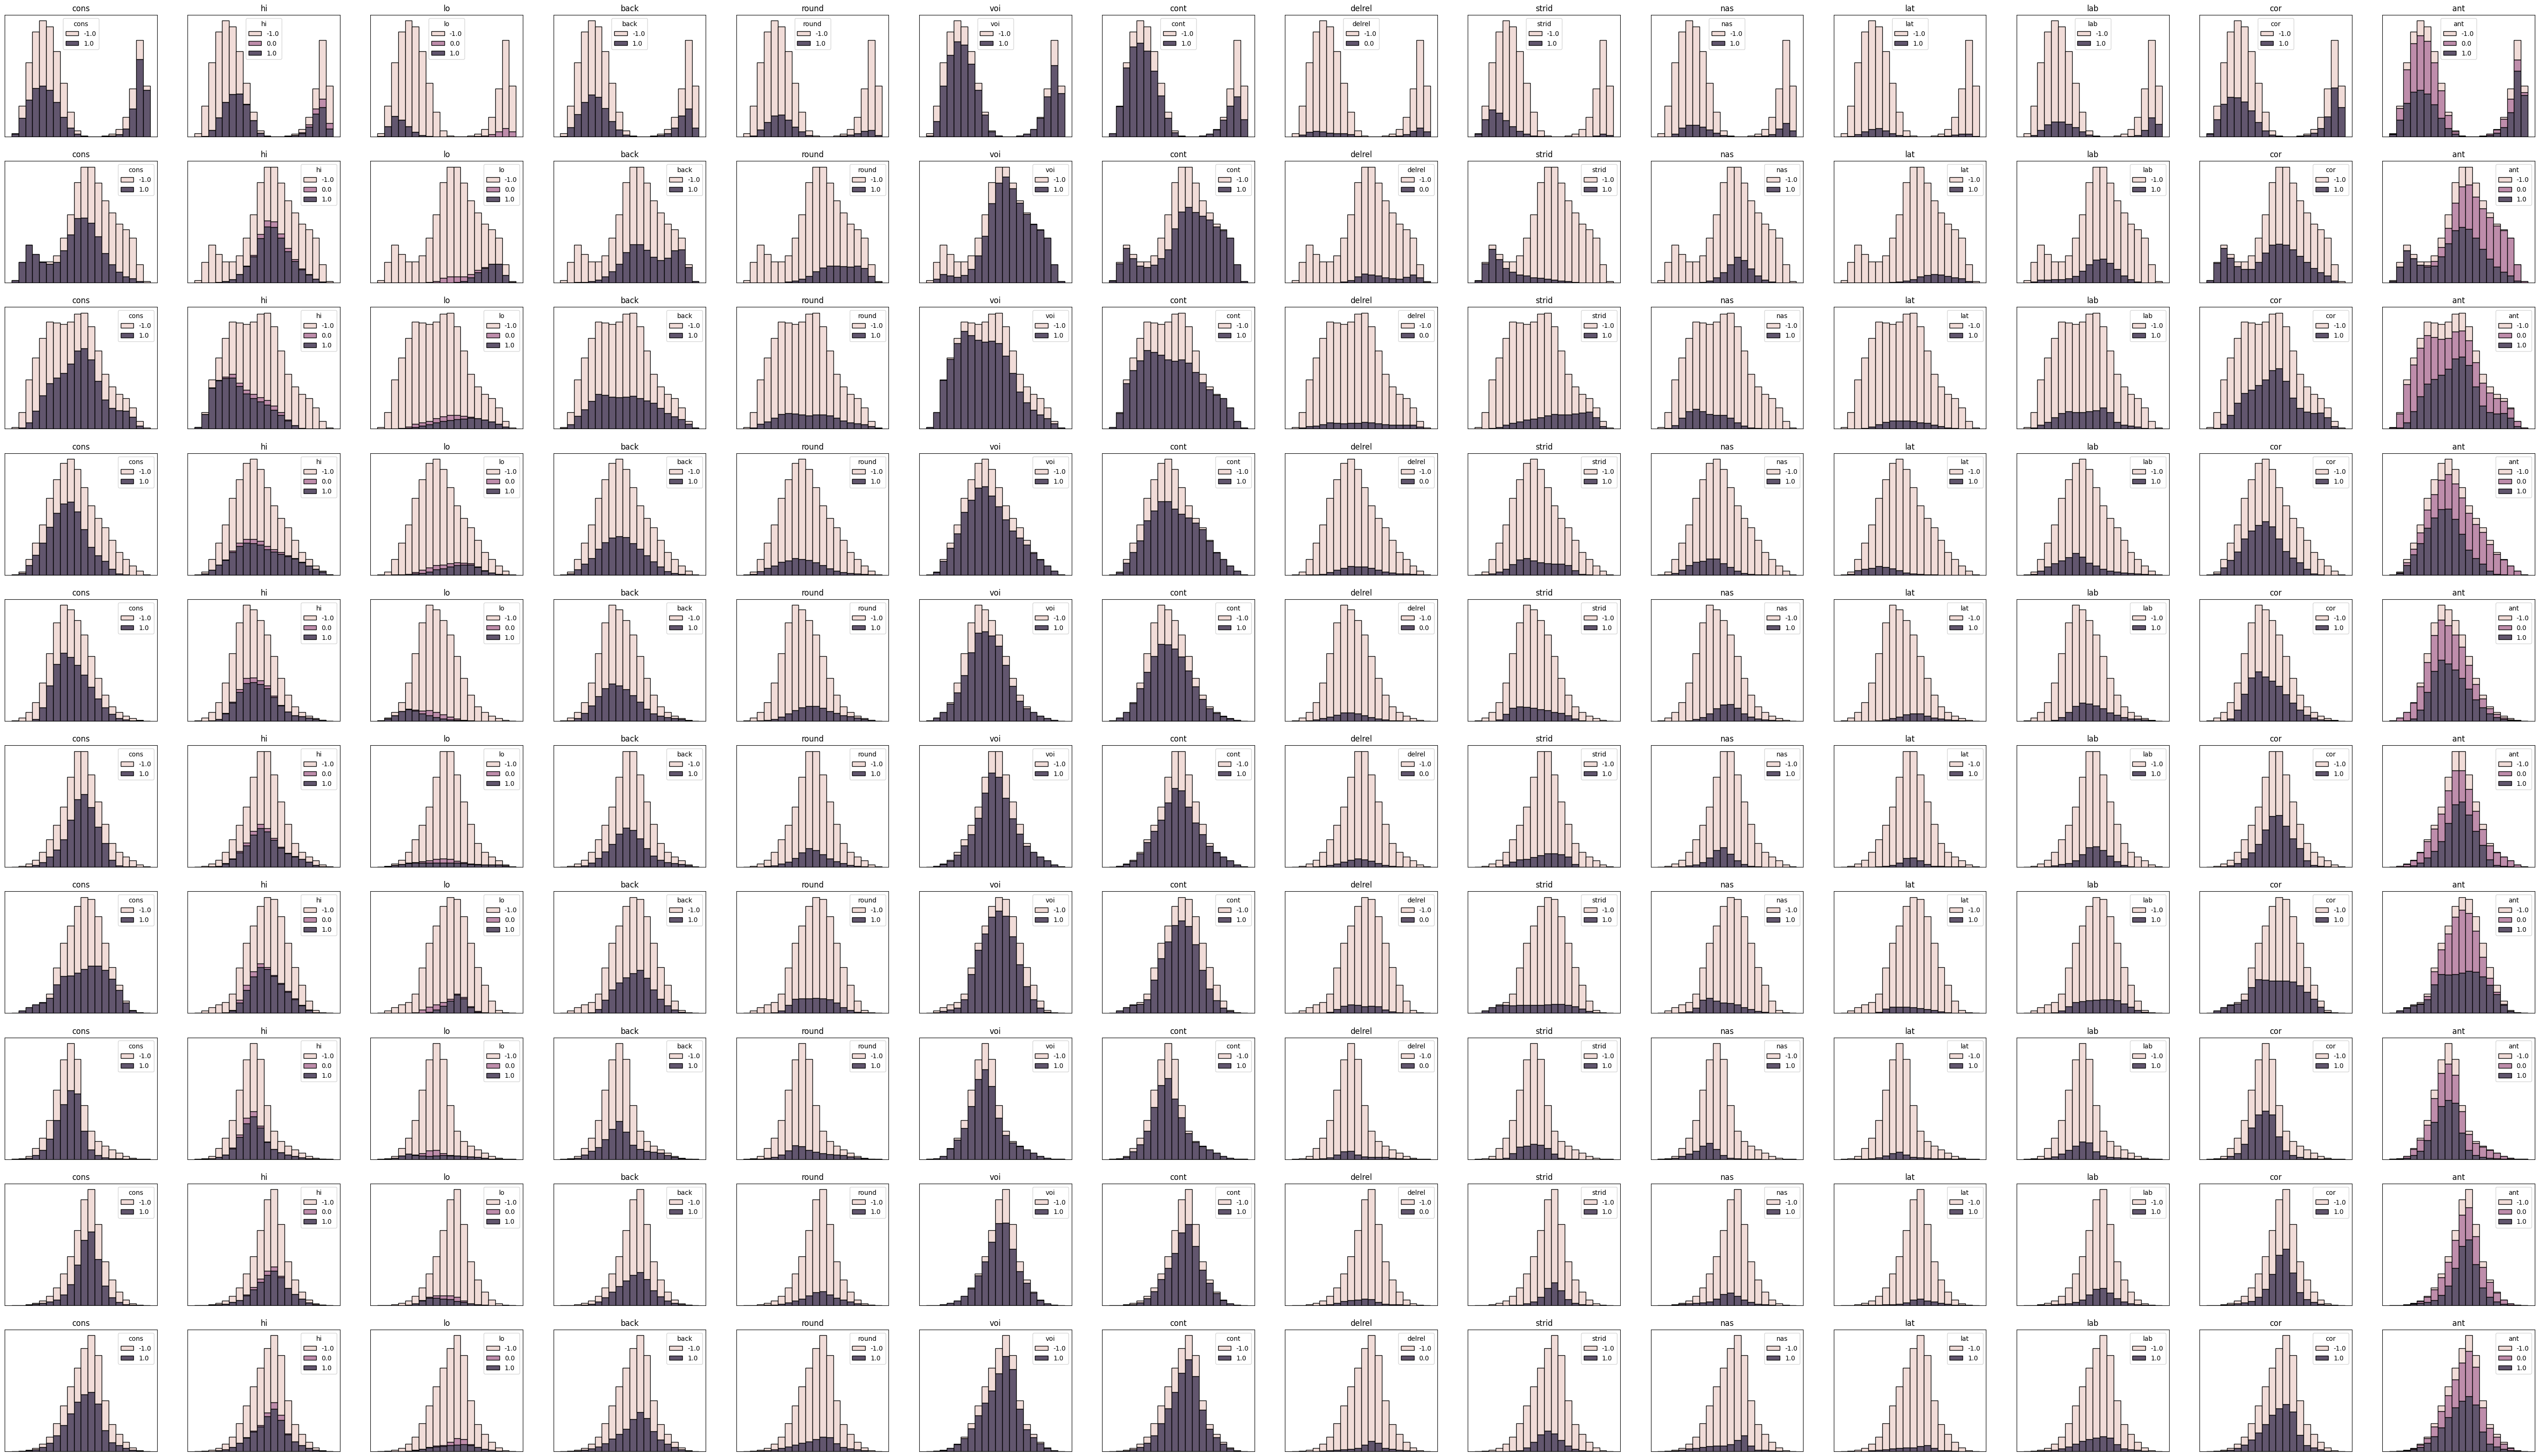

In [8]:
fig, axes = plt.subplots(
    len(pca_feats.T), len(panphon_feats), figsize=(5 * len(panphon_feats), 4 * len(pca_feats.T))
)

for pca_feat, ax_row in zip(pca_feats.T, axes):
    for panphon_feat, ax in zip(panphon_feats, ax_row):
        sns.histplot(
            data=pd.DataFrame({"value": pca_feat, panphon_feat: _df[panphon_feat]}, ),
            x="value",
            hue=panphon_feat,
            bins=20, multiple="stack", ax=ax,
        )
        ax.set_title(f'{panphon_feat}')
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(left=False, bottom=False)
        ax.set_xticks([])
        ax.set_yticks([])

In [9]:
pca_df = pd.DataFrame(
    [
        [
            max(average_precision_score(df.allophone == ipa, pca_feats[:, i]), average_precision_score(df.allophone == ipa, -pca_feats[:, i]))
            for i in range(10)
        ]
        for ipa in arpa_ipa.values()
    ],
    index=list(arpa_ipa.values()), columns=list(range(10)))
pca_df

,0,1,2,3,4,5,6,7,8,9
ɑ,0.052595,0.215792,0.156828,0.021618,0.042858,0.025044,0.028382,0.045275,0.056409,0.058102
æ,0.079010,0.072487,0.034336,0.099035,0.362097,0.236642,0.033837,0.038752,0.049050,0.038138
ʌ,0.029384,0.071913,0.021986,0.023669,0.049823,0.019052,0.015269,0.025581,0.018800,0.031072
ɔ,0.031324,0.095218,0.180942,0.020652,0.054210,0.026189,0.029113,0.043450,0.033434,0.040764
aʊ,0.014357,0.025615,0.017462,0.008629,0.008425,0.013230,0.006074,0.049818,0.011899,0.024716
ə,0.031078,0.034811,0.024992,0.059675,0.026480,0.027641,0.038356,0.025966,0.031824,0.031778
ə̥,0.013148,0.003122,0.002476,0.002461,0.002855,0.002372,0.002853,0.002429,0.002395,0.002405
ɚ,0.026609,0.036219,0.034915,0.025795,0.026287,0.044468,0.027000,0.044160,0.082045,0.034679
aɪ,0.151143,0.116319,0.061358,0.044993,0.100156,0.288690,0.020748,0.167166,0.044271,0.038985
b,0.129955,0.019248,0.025316,0.016398,0.014747,0.027736,0.025886,0.021802,0.015620,0.023418


In [10]:
for col in pca_df.columns:
    top_rows = pca_df[col].nlargest(5)
    print(f'\nTop 5 for PC {col}')
    for row_name, value in top_rows.items():
        print(f'Allophone: {row_name} | mAP: {value:.4f}')


Top 5 for PC 0
Allophone: s | mAP: 0.3174
Allophone: d | mAP: 0.1681
Allophone: aɪ | mAP: 0.1511
Allophone: b | mAP: 0.1300
Allophone: ɾ | mAP: 0.1021

Top 5 for PC 1
Allophone: s | mAP: 0.4501
Allophone: ɑ | mAP: 0.2158
Allophone: ʃ | mAP: 0.2133
Allophone: z | mAP: 0.1460
Allophone: oʊ | mAP: 0.1245

Top 5 for PC 2
Allophone: i | mAP: 0.2711
Allophone: s | mAP: 0.2660
Allophone: ɔ | mAP: 0.1809
Allophone: ɑ | mAP: 0.1568
Allophone: ɨ | mAP: 0.1406

Top 5 for PC 3
Allophone: i | mAP: 0.3195
Allophone: eɪ | mAP: 0.1768
Allophone: l | mAP: 0.1530
Allophone: æ | mAP: 0.0990
Allophone: ɹ | mAP: 0.0867

Top 5 for PC 4
Allophone: æ | mAP: 0.3621
Allophone: w | mAP: 0.1496
Allophone: ɛ | mAP: 0.1074
Allophone: aɪ | mAP: 0.1002
Allophone: i | mAP: 0.0995

Top 5 for PC 5
Allophone: aɪ | mAP: 0.2887
Allophone: æ | mAP: 0.2366
Allophone: i | mAP: 0.1943
Allophone: eɪ | mAP: 0.1069
Allophone: ɨ | mAP: 0.0878

Top 5 for PC 6
Allophone: s | mAP: 0.2430
Allophone: z | mAP: 0.1692
Allophone: t | mAP

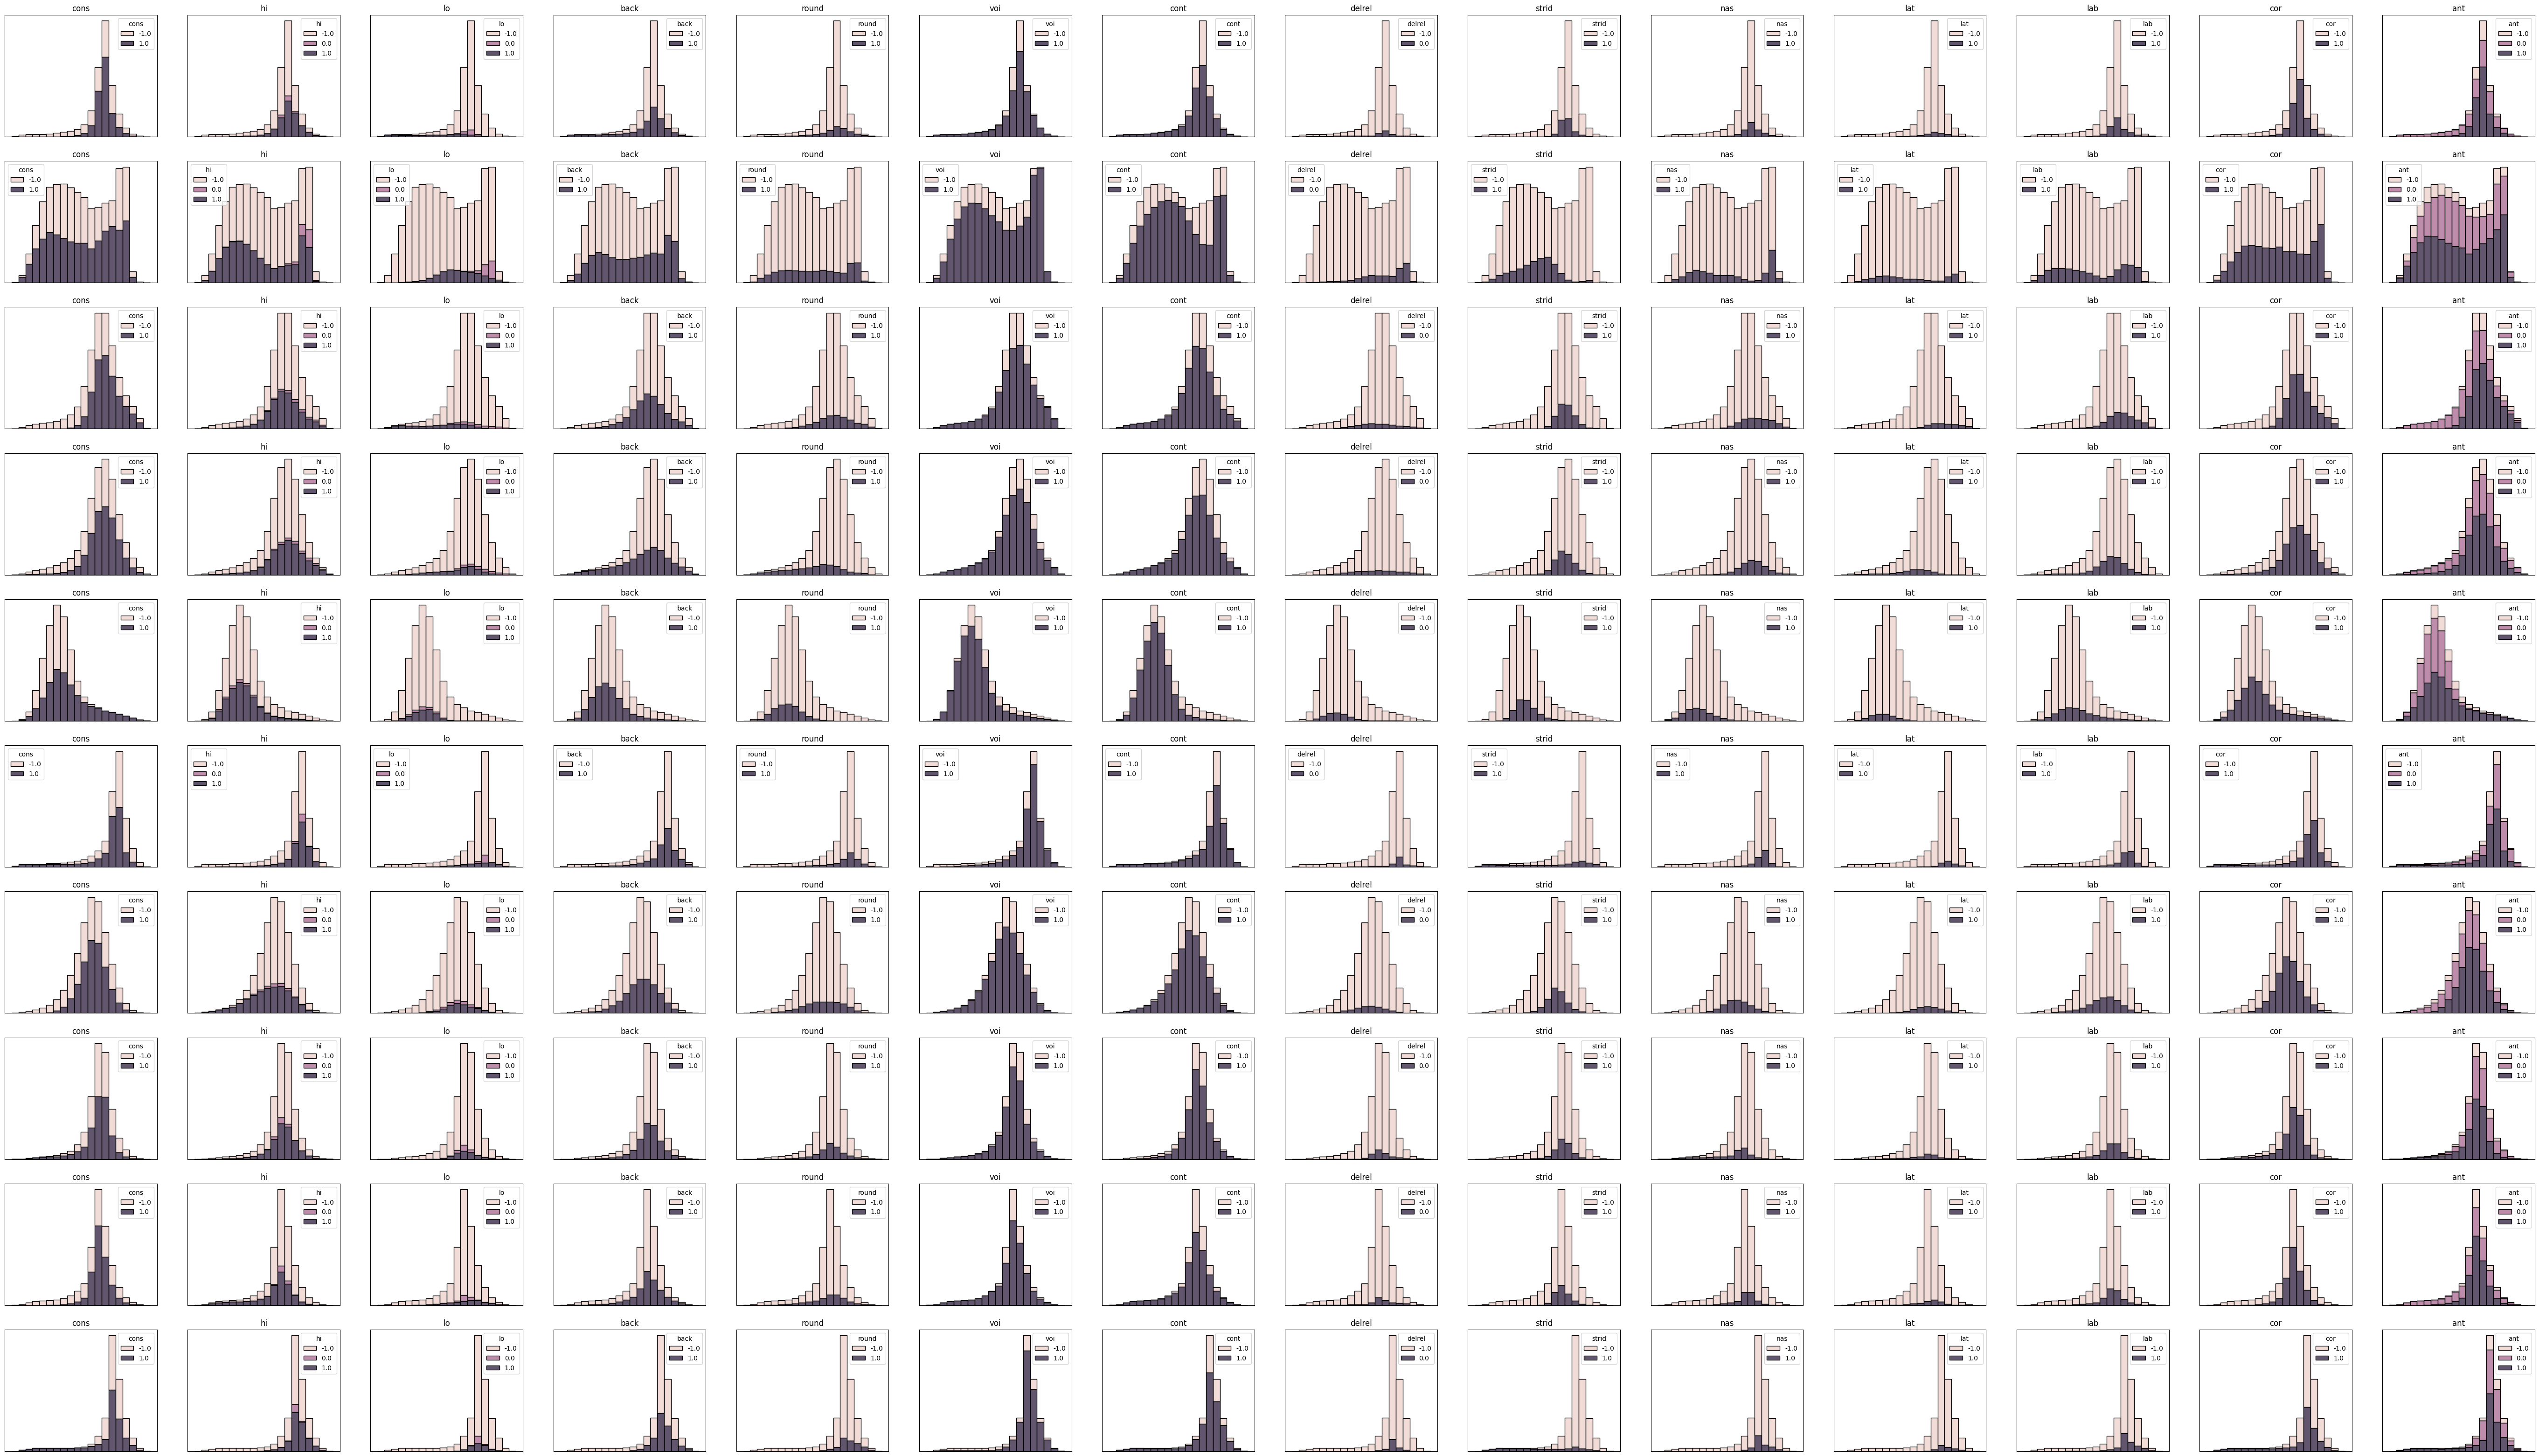

In [11]:
fig, axes = plt.subplots(
    len(pca_feats.T), len(panphon_feats), figsize=(5 * len(panphon_feats), 4 * len(pca_feats.T))
)

for pca_feat, ax_row in zip(ica_feats.T, axes):
    for panphon_feat, ax in zip(panphon_feats, ax_row):
        sns.histplot(
            data=pd.DataFrame({"value": pca_feat, panphon_feat: _df[panphon_feat]}, ),
            x="value",
            hue=panphon_feat,
            bins=20, multiple="stack", ax=ax,
        )
        ax.set_title(f'{panphon_feat}')
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(left=False, bottom=False)
        ax.set_xticks([])
        ax.set_yticks([])

In [12]:
ica_df = pd.DataFrame(
    [
        [
            max(average_precision_score(df.allophone == ipa, ica_feats[:, i]), average_precision_score(df.allophone == ipa, -ica_feats[:, i]))
            for i in range(10)
        ]
        for ipa in arpa_ipa.values()
    ],
    index=list(arpa_ipa.values()), columns=list(range(10)))
ica_df

,0,1,2,3,4,5,6,7,8,9
ɑ,0.146438,0.025208,0.046093,0.076535,0.025251,0.054491,0.021639,0.043396,0.116116,0.023667
æ,0.082370,0.038740,0.503904,0.033269,0.030912,0.036121,0.046585,0.029615,0.037815,0.033322
ʌ,0.046341,0.016561,0.031506,0.028764,0.028773,0.059849,0.035586,0.030254,0.041623,0.016809
ɔ,0.063143,0.024809,0.022841,0.124142,0.035871,0.048073,0.024780,0.028697,0.062238,0.075817
aʊ,0.007344,0.120708,0.069493,0.040709,0.004947,0.007331,0.004895,0.007117,0.008864,0.010140
ə,0.031327,0.053321,0.066747,0.029744,0.041325,0.038786,0.041498,0.026377,0.034465,0.024237
ə̥,0.002899,0.005594,0.003698,0.005084,0.005214,0.002514,0.002502,0.002871,0.002405,0.002609
ɚ,0.113693,0.024097,0.041147,0.036939,0.042778,0.038184,0.053659,0.041052,0.038244,0.037235
aɪ,0.725509,0.016383,0.019268,0.015585,0.017102,0.020319,0.015617,0.018818,0.035979,0.024506
b,0.015375,0.033436,0.037888,0.016769,0.085190,0.015810,0.015250,0.016424,0.014805,0.015411


In [16]:
for col in ica_df.columns:
    top_rows = ica_df[col].nlargest(5)
    bottom_rows = ica_df[col].nsmallest(5)

    print(f'\nTop/Bottom 5 for IC {col}')
    for row_name, value in top_rows.items():
        print(f'Allophone: {row_name} | mAP: {value:.4f}')
    print("...")
    for row_name, value in bottom_rows.items():
        print(f'Allophone: {row_name} | mAP: {value:.4f}')


Top/Bottom 5 for IC 0
Allophone: aɪ | mAP: 0.7255
Allophone: ɑ | mAP: 0.1464
Allophone: ɚ | mAP: 0.1137
Allophone: ʉ | mAP: 0.1121
Allophone: ɨ | mAP: 0.0892
...
Allophone: ŋ̍ | mAP: 0.0004
Allophone: m̩ | mAP: 0.0010
Allophone: ʒ | mAP: 0.0013
Allophone: ə̥ | mAP: 0.0029
Allophone: θ | mAP: 0.0055

Top/Bottom 5 for IC 1
Allophone: aʊ | mAP: 0.1207
Allophone: n | mAP: 0.0986
Allophone: ɨ | mAP: 0.0780
Allophone: ɾ | mAP: 0.0717
Allophone: i | mAP: 0.0677
...
Allophone: ŋ̍ | mAP: 0.0003
Allophone: m̩ | mAP: 0.0011
Allophone: ʒ | mAP: 0.0018
Allophone: ʊ | mAP: 0.0048
Allophone: ɔɪ | mAP: 0.0054

Top/Bottom 5 for IC 2
Allophone: æ | mAP: 0.5039
Allophone: ɛ | mAP: 0.1401
Allophone: l | mAP: 0.1290
Allophone: n | mAP: 0.0800
Allophone: ɨ | mAP: 0.0761
...
Allophone: ŋ̍ | mAP: 0.0003
Allophone: ʒ | mAP: 0.0011
Allophone: m̩ | mAP: 0.0012
Allophone: ə̥ | mAP: 0.0037
Allophone: u | mAP: 0.0039

Top/Bottom 5 for IC 3
Allophone: oʊ | mAP: 0.2525
Allophone: ɨ | mAP: 0.2268
Allophone: ɔ | mAP: 

/home/kwanghec/unbox-w2v-convnet/envs/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


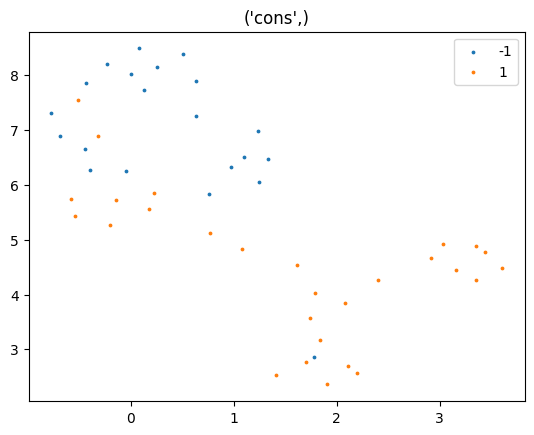

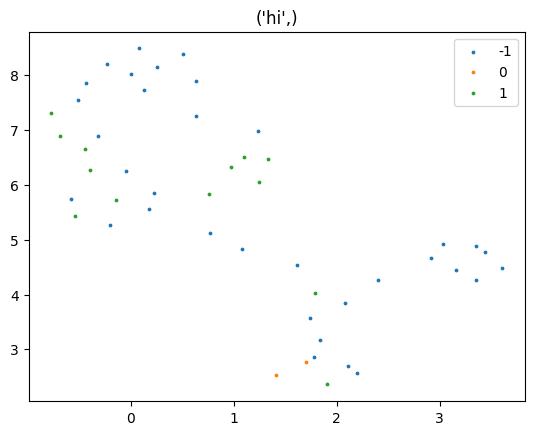

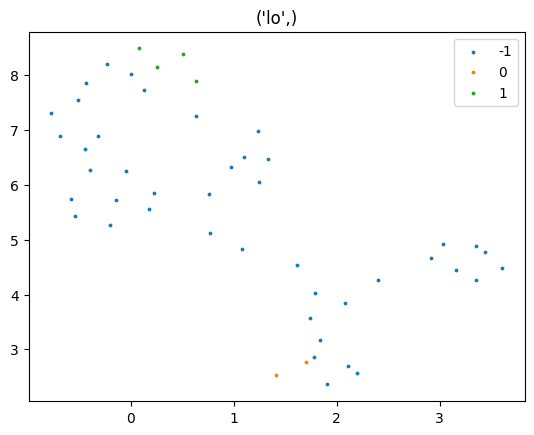

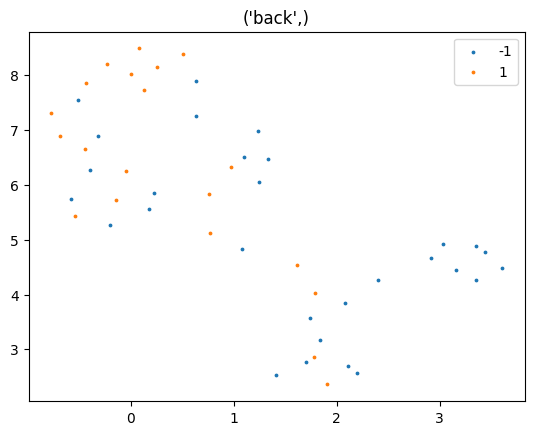

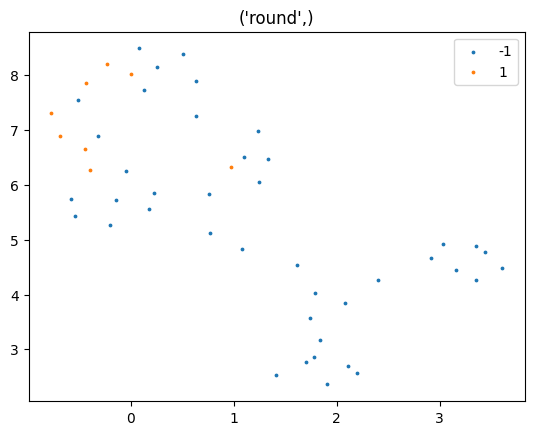

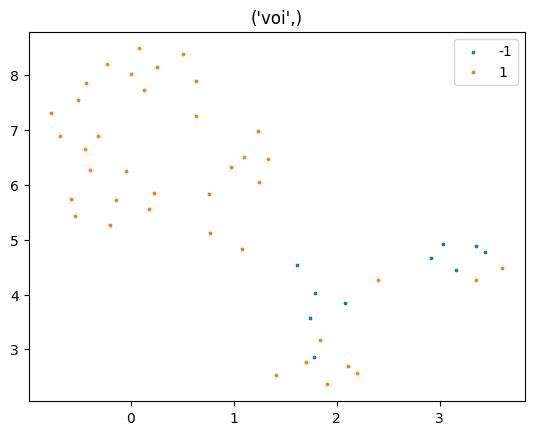

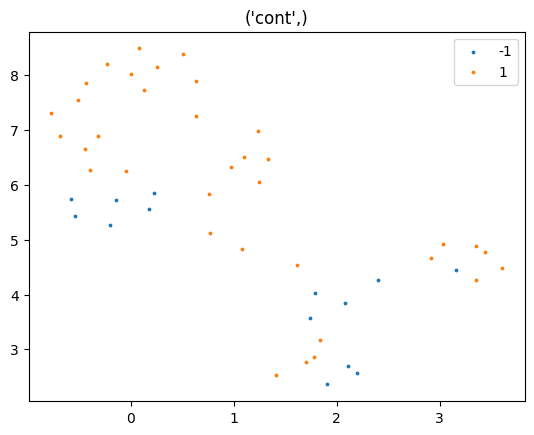

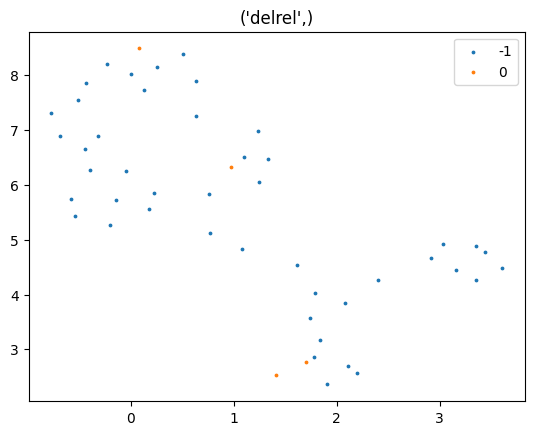

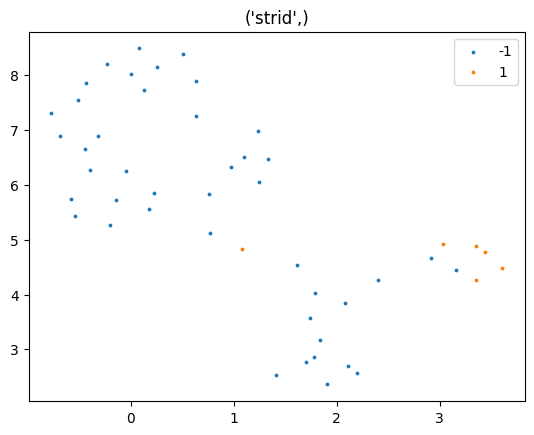

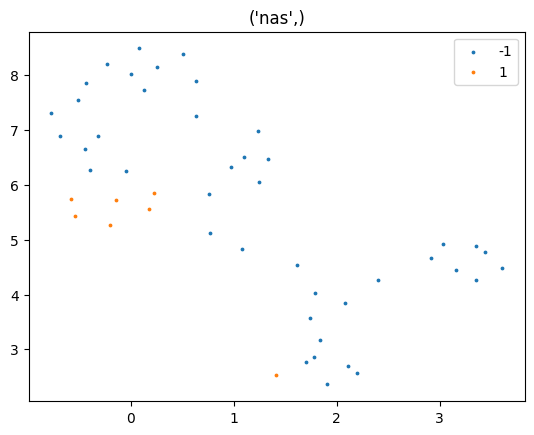

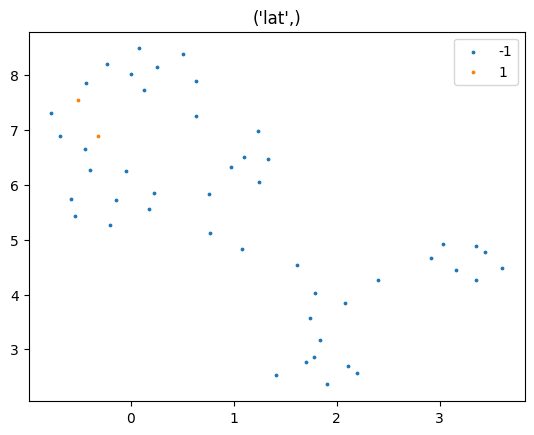

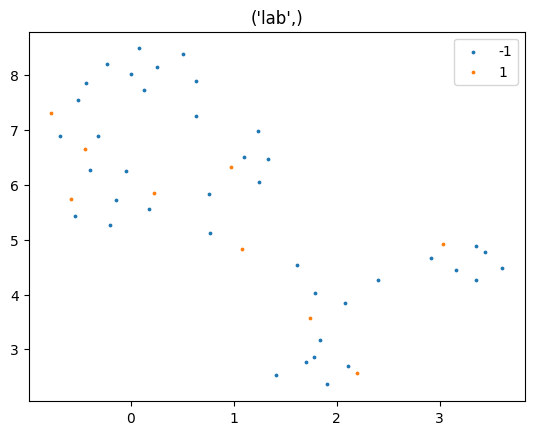

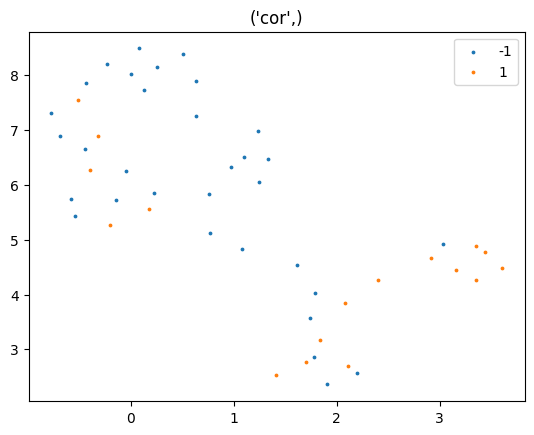

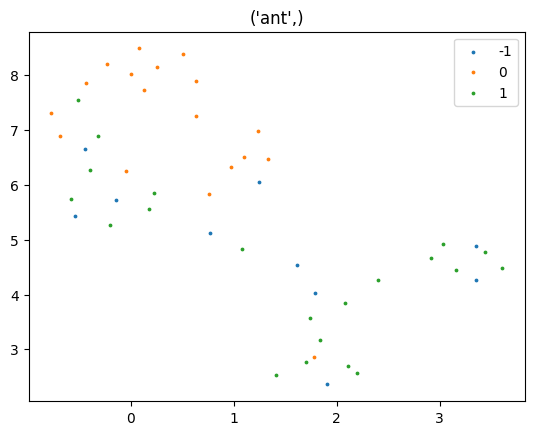

In [40]:
labels = []
panphon_labels = []
feats = []
for p1 in df.allophone.unique():
    if np.isnan(ipa_feat[p1][0]):
        continue
    labels.append(f"{p1}")
    feats.append(_avg(p1))
    panphon_labels.append(np.array([f"{f1}" for f1 in ipa_feat[p1]]))

feats = np.array(feats)
panphon_labels = np.array(panphon_labels)

import umap
embs = umap.UMAP().fit_transform(feats)

for i, feat_name in enumerate(zip(panphon_feats)):
    for label in np.unique(panphon_labels[:, i]):
        if "nan" not in label:
            mask = (panphon_labels[:, i] == label)
            plt.scatter(embs[mask, 0], embs[mask, 1], s=3, label=label)
    plt.title(feat_name)
    plt.legend()
    plt.show()

In [36]:
from functools import lru_cache

@lru_cache(maxsize=128)
def _avg(allophone):
    return np.array(df[df.allophone == allophone].feat.tolist()).mean(0)

labels = []
panphon_labels = []
feats = []
for p1 in df.allophone.unique():
    for p2 in df.allophone.unique():
        if (p1 == p2) or np.isnan(ipa_feat[p1][0]) or np.isnan(ipa_feat[p2][0]):
            continue
        labels.append(f"{p1}-{p2}")
        feats.append(_avg(p1) - _avg(p2))
        panphon_labels.append(np.array([f"{f1},{f2}" for f1, f2 in zip(ipa_feat[p1], ipa_feat[p2])]))

        labels.append(f"{p2}-{p1}")
        feats.append(_avg(p2) - _avg(p1))
        panphon_labels.append(np.array([f"{f2},{f1}" for f1, f2 in zip(ipa_feat[p1], ipa_feat[p2])]))

feats = np.array(feats)
panphon_labels = np.array(panphon_labels)


In [37]:
import umap
embs = umap.UMAP().fit_transform(feats)
# ipa_feats

/home/kwanghec/unbox-w2v-convnet/envs/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


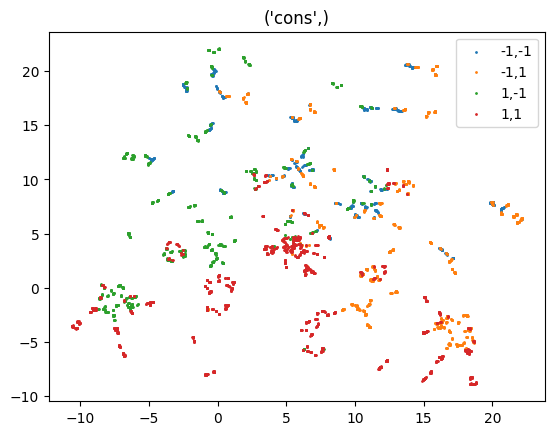

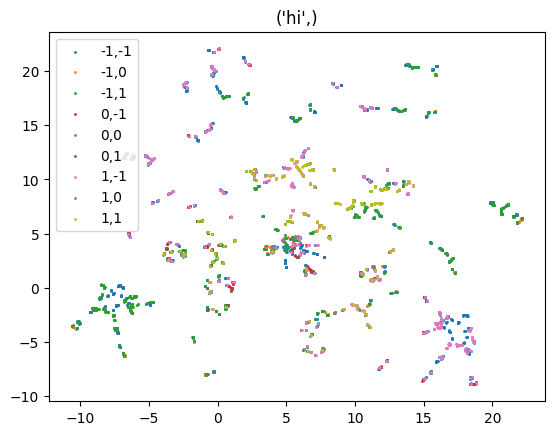

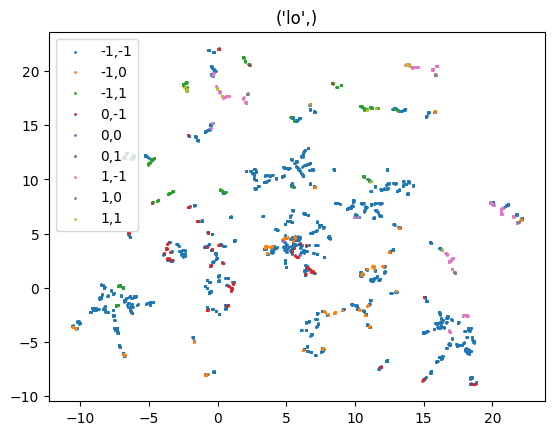

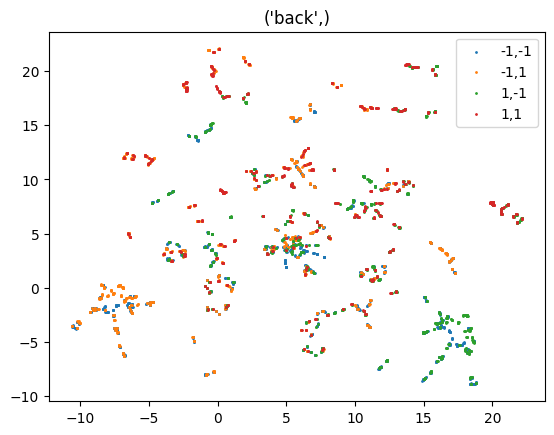

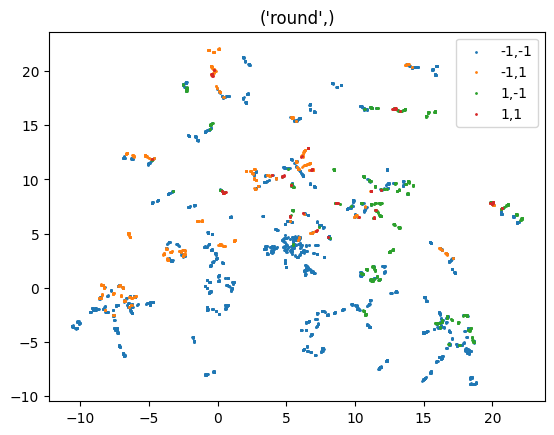

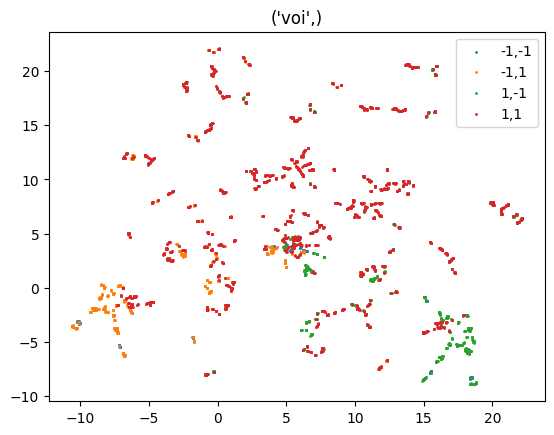

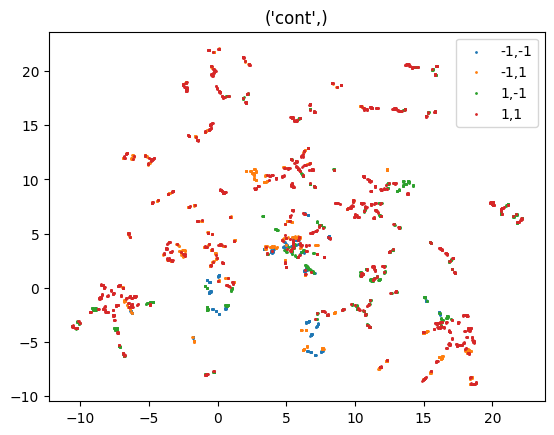

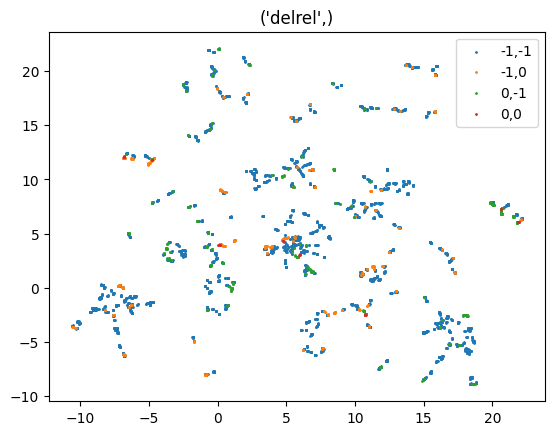

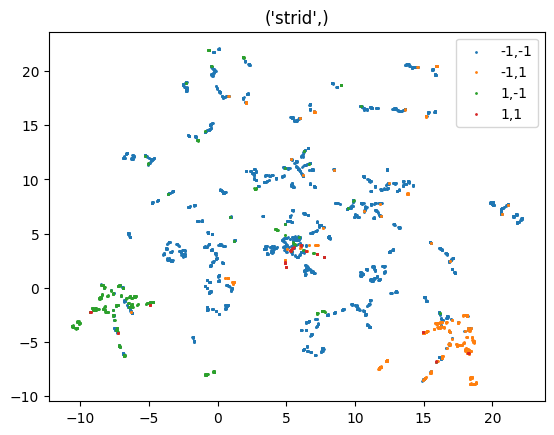

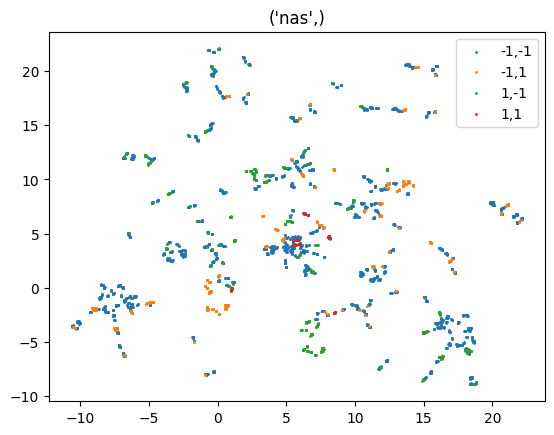

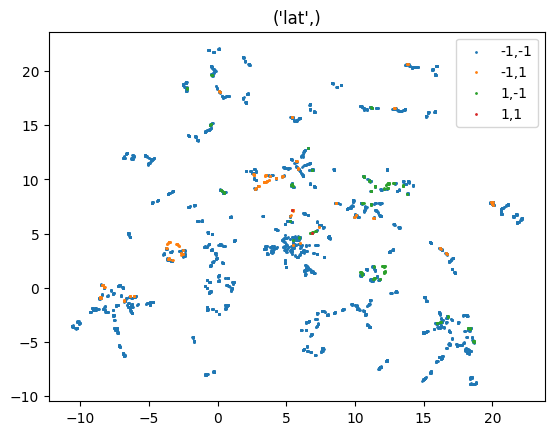

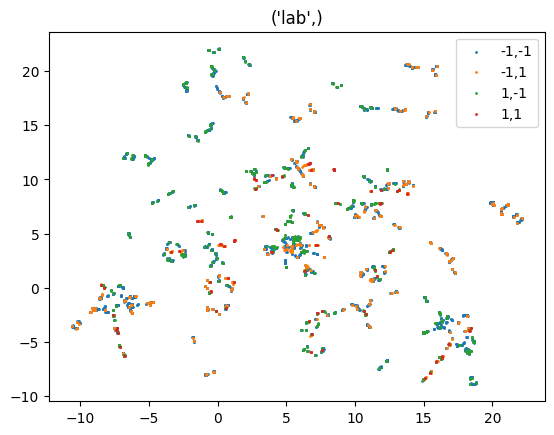

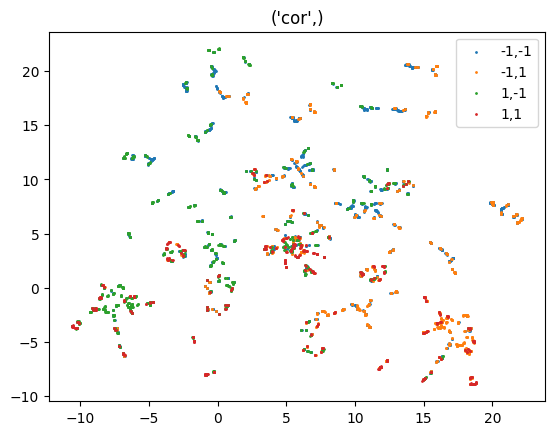

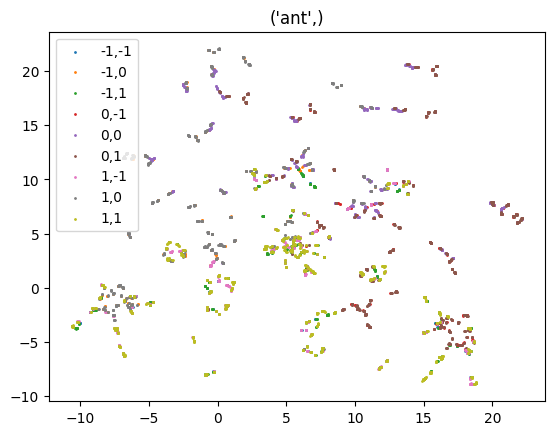

In [38]:
for i, feat_name in enumerate(zip(panphon_feats)):
    for label in np.unique(panphon_labels[:, i]):
        if "nan" not in label:
            mask = (panphon_labels[:, i] == label)
            plt.scatter(embs[mask, 0], embs[mask, 1], s=1, label=label)
    plt.title(feat_name)
    plt.legend()
    plt.show()